In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [ ]:
from google.colab import files

def save_plot(filename):
    path = f"{filename}.eps"
    plt.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    files.download(path)
    print(f"Saved and downloaded: {path}")


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1648s 10us/step


In [ ]:
class_names=['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape :", x_test.shape, y_test.shape)

Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape : (10000, 32, 32, 3) (10000, 1)


In [ ]:
#Normalization
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot1_class_distribution.eps


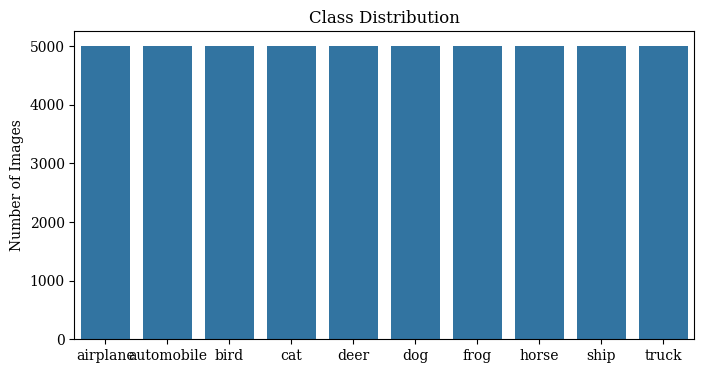

In [ ]:
#Class Distribution
plt.figure(figsize=(8,4))

unique, counts = np.unique(y_train, return_counts=True)

sns.barplot(x=class_names, y=counts)


plt.title("Class Distribution")
plt.ylabel("Number of Images")
save_plot("plot1_class_distribution")
plt.show()


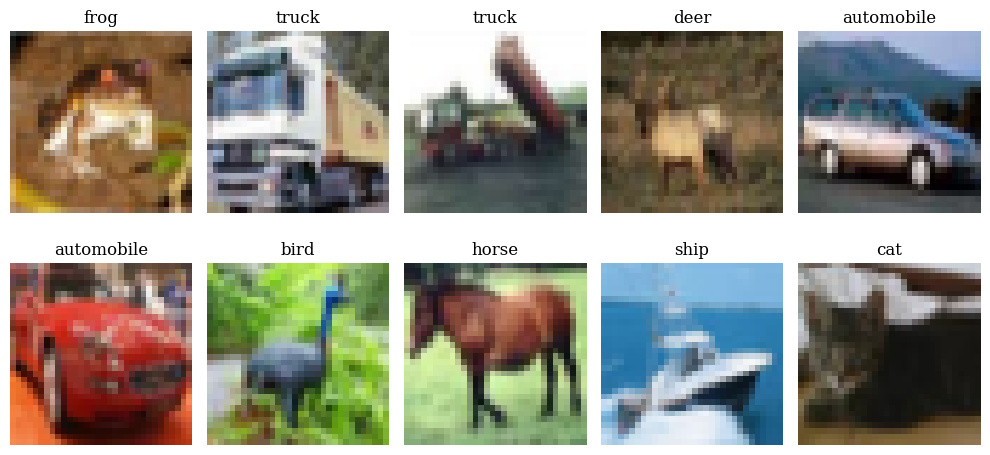

In [ ]:

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
#save_plot("plot2_class_images")
plt.show()

In [ ]:
kernel_sizes = [3, 5, 7]
feature_map_sizes = {}

sample_image = x_train[:1]

for kernel_size in kernel_sizes:

    conv_layer = layers.Conv2D(
        filters=16,
        kernel_size=(kernel_size, kernel_size),
        strides=1,
        padding="valid"
    )

    output = conv_layer(sample_image)

    feature_map_sizes[f"{kernel_size}x{kernel_size}"] = output.shape

    print(f"Kernel Size: {kernel_size}x{kernel_size}")
    print(f"Output Feature Map Shape: {output.shape}")
    print("-" * 40)

Kernel Size: 3x3
Output Feature Map Shape: (1, 30, 30, 16)
----------------------------------------
Kernel Size: 5x5
Output Feature Map Shape: (1, 28, 28, 16)
----------------------------------------
Kernel Size: 7x7
Output Feature Map Shape: (1, 26, 26, 16)
----------------------------------------


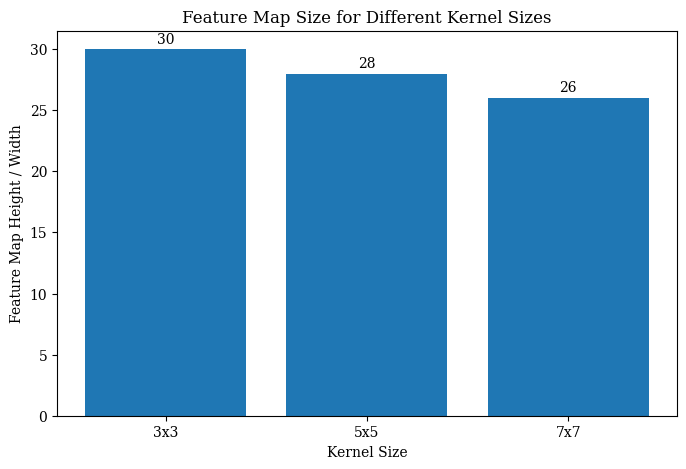

In [ ]:
kernel_labels = ["3x3", "5x5", "7x7"]

heights = [
    feature_map_sizes[label][1]
    for label in kernel_labels
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(kernel_labels, heights)

ax.set_title("Feature Map Size for Different Kernel Sizes")
ax.set_xlabel("Kernel Size")
ax.set_ylabel("Feature Map Height / Width")

for i, value in enumerate(heights):
    ax.text(i, value + 0.5, str(value), ha="center")

#save_plot(fig)

plt.show()

In [ ]:
import math

def compute_output_size(input_size, kernel_size, stride=1, padding="valid"):

    if padding.lower() == "same":
        return math.ceil(input_size / stride)

    elif padding.lower() == "valid":
        return math.floor(
            (input_size - kernel_size) / stride
        ) + 1

    else:
        raise ValueError("Padding must be 'same' or 'valid'")

In [ ]:
input_size = 32
kernel_size = 3

for stride in [1, 2]:

    output_size = compute_output_size(
        input_size,
        kernel_size,
        stride=stride,
        padding="valid"
    )

    print(
        f"Stride = {stride}, Padding = Valid "
        f"-> Output Size = {output_size} x {output_size}"
    )

Stride = 1, Padding = Valid -> Output Size = 30 x 30
Stride = 2, Padding = Valid -> Output Size = 15 x 15


In [ ]:
for padding in ["same", "valid"]:

    output_size = compute_output_size(
        input_size=32,
        kernel_size=3,
        stride=1,
        padding=padding
    )

    print(
        f"Padding = {padding.upper()} "
        f"-> Output Size = {output_size} x {output_size}"
    )

Padding = SAME -> Output Size = 32 x 32
Padding = VALID -> Output Size = 30 x 30


In [ ]:
configurations = [
    {"stride": 1, "padding": "valid"},
    {"stride": 2, "padding": "valid"},
    {"stride": 1, "padding": "same"},
    {"stride": 2, "padding": "same"}
]

sample_image = x_train[:1]

for config in configurations:

    conv = layers.Conv2D(
        filters=8,
        kernel_size=3,
        strides=config["stride"],
        padding=config["padding"]
    )

    output = conv(sample_image)

    print(
        f"Stride = {config['stride']}, "
        f"Padding = {config['padding'].upper()}"
    )

    print("Output shape:", output.shape)
    print("-" * 50)

Stride = 1, Padding = VALID
Output shape: (1, 30, 30, 8)
--------------------------------------------------
Stride = 2, Padding = VALID
Output shape: (1, 15, 15, 8)
--------------------------------------------------
Stride = 1, Padding = SAME
Output shape: (1, 32, 32, 8)
--------------------------------------------------
Stride = 2, Padding = SAME
Output shape: (1, 16, 16, 8)
--------------------------------------------------


In [ ]:
conv_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        filters=16,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="first_conv"
    )
])

conv_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ first_conv (Conv2D)             │ (None, 32, 32, 16)     │           448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 448 (1.75 KB)

 Trainable params: 448 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
image = x_train[0:1]

feature_maps = conv_model.predict(image, verbose=0)

print("Input image shape:", image.shape)
print("Feature maps shape:", feature_maps.shape)

Input image shape: (1, 32, 32, 3)
Feature maps shape: (1, 32, 32, 16)


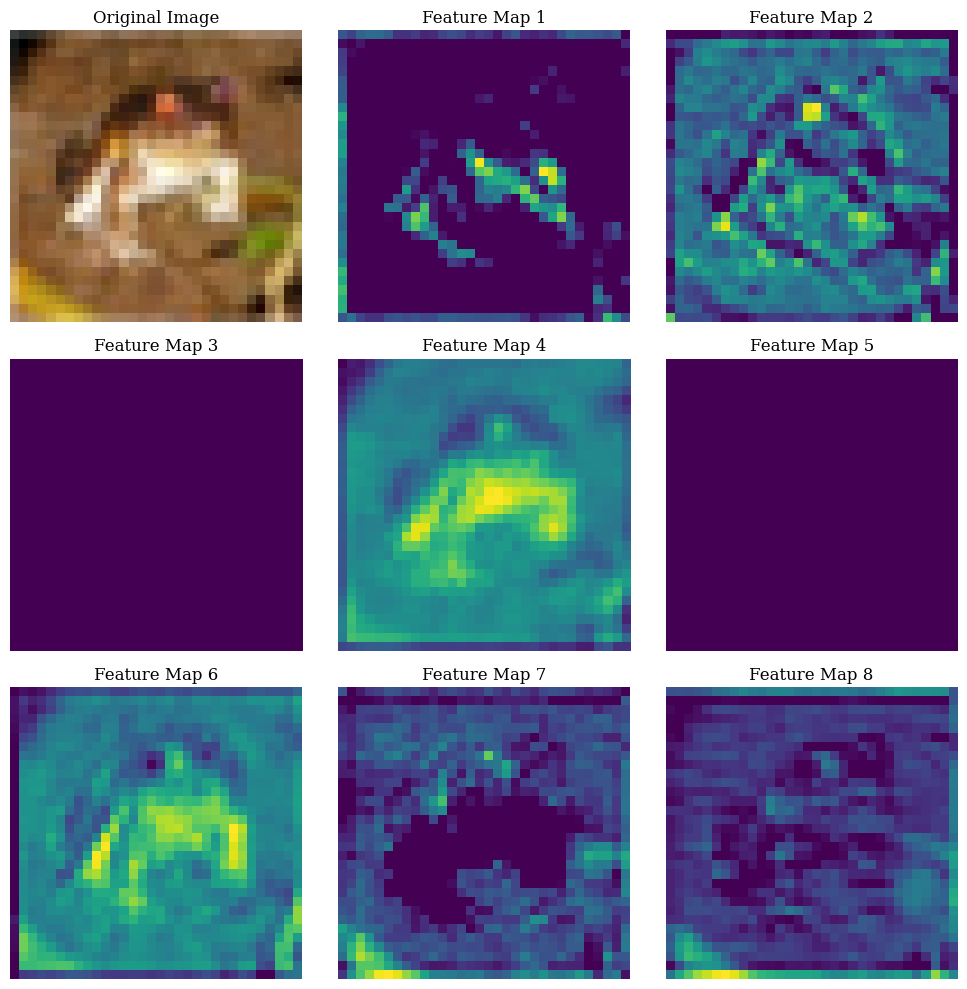

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Original image
axes[0, 0].imshow(x_train[0])
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Display 8 feature maps
for i in range(8):

    row = (i + 1) // 3
    col = (i + 1) % 3

    axes[row, col].imshow(
        feature_maps[0, :, :, i],
        cmap="viridis"
    )

    axes[row, col].set_title(f"Feature Map {i + 1}")
    axes[row, col].axis("off")

fig.tight_layout()

#save_plot(fig)

plt.show()

In [ ]:
sample_feature_map = tf.random.normal((1, 32, 32, 16))

max_pool = layers.MaxPooling2D(pool_size=(2, 2))
avg_pool = layers.AveragePooling2D(pool_size=(2, 2))

max_output = max_pool(sample_feature_map)
avg_output = avg_pool(sample_feature_map)

print("Input Feature Map Shape:", sample_feature_map.shape)
print("Max Pooling Output Shape:", max_output.shape)
print("Average Pooling Output Shape:", avg_output.shape)

Input Feature Map Shape: (1, 32, 32, 16)
Max Pooling Output Shape: (1, 16, 16, 16)
Average Pooling Output Shape: (1, 16, 16, 16)


In [ ]:
def create_pooling_model(pooling_type="max"):

    if pooling_type == "max":
        pooling_layer = layers.MaxPooling2D

    elif pooling_type == "average":
        pooling_layer = layers.AveragePooling2D

    else:
        raise ValueError("pooling_type must be 'max' or 'average'")

    model = models.Sequential([

        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        pooling_layer(pool_size=(2, 2)),

        layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        pooling_layer(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
max_pool_model = create_pooling_model("max")

history_max = max_pool_model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 116s 73ms/step - accuracy: 0.5206 - loss: 1.3486 - val_accuracy: 0.5783 - val_loss: 1.2074
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 125s 63ms/step - accuracy: 0.6479 - loss: 0.9942 - val_accuracy: 0.6462 - val_loss: 1.0110
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.7027 - loss: 0.8538 - val_accuracy: 0.6742 - val_loss: 0.9395
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.7388 - loss: 0.7474 - val_accuracy: 0.7031 - val_loss: 0.8784
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.7704 - loss: 0.6581 - val_accuracy: 0.7099 - val_loss: 0.8569
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.8010 - loss: 0.5697 - val_accuracy: 0.7016 - val_loss: 0.9258
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.8251 - loss: 0.4955 - val_accuracy: 0.7004 - val_loss: 0.9351
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 56ms/step - accuracy: 0.854

In [ ]:
avg_pool_model = create_pooling_model("average")

history_avg = avg_pool_model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.4740 - loss: 1.4554 - val_accuracy: 0.5698 - val_loss: 1.2010
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.6112 - loss: 1.0983 - val_accuracy: 0.6270 - val_loss: 1.0680
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.6648 - loss: 0.9523 - val_accuracy: 0.6467 - val_loss: 1.0142
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.6996 - loss: 0.8567 - val_accuracy: 0.6659 - val_loss: 0.9536
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.7259 - loss: 0.7830 - val_accuracy: 0.6848 - val_loss: 0.9080
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.7509 - loss: 0.7145 - val_accuracy: 0.6793 - val_loss: 0.9187
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.7674 - loss: 0.6607 - val_accuracy: 0.6993 - val_loss: 0.8833
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.7866 -

In [ ]:
max_loss, max_accuracy = max_pool_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

avg_loss, avg_accuracy = avg_pool_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("MAX POOLING")
print("Output size after 2x2 pooling: 16 x 16")
print(f"Test Accuracy: {max_accuracy:.4f}")

print("\nAVERAGE POOLING")
print("Output size after 2x2 pooling: 16 x 16")
print(f"Test Accuracy: {avg_accuracy:.4f}")

MAX POOLING
Output size after 2x2 pooling: 16 x 16
Test Accuracy: 0.7031

AVERAGE POOLING
Output size after 2x2 pooling: 16 x 16
Test Accuracy: 0.7108


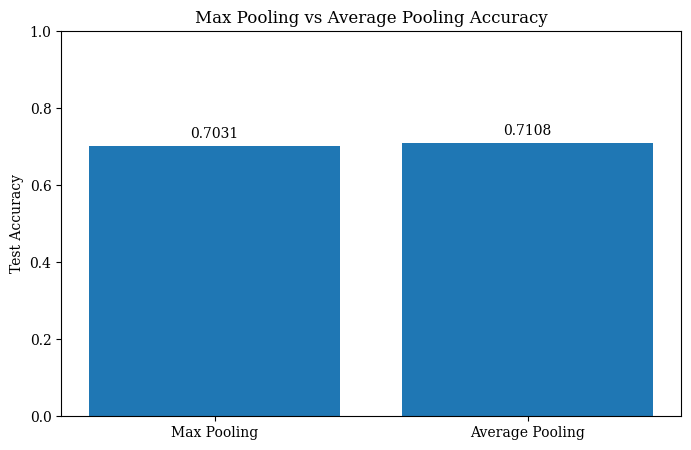

In [ ]:
pooling_methods = ["Max Pooling", "Average Pooling"]
accuracies = [
    max_accuracy,
    avg_accuracy
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(pooling_methods, accuracies)

ax.set_title("Max Pooling vs Average Pooling Accuracy")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1)

for i, value in enumerate(accuracies):
    ax.text(
        i,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

#save_plot(fig)

plt.show()

In [ ]:
cnn_model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    # First Convolution Block
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same"
    ),

    layers.ReLU(),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),


    # Second Convolution Block
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same"
    ),

    layers.ReLU(),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),


    # Classification layers
    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = cnn_model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 59ms/step - accuracy: 0.5179 - loss: 1.3514 - val_accuracy: 0.5995 - val_loss: 1.1207
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.6548 - loss: 0.9850 - val_accuracy: 0.6718 - val_loss: 0.9487
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 60ms/step - accuracy: 0.7027 - loss: 0.8483 - val_accuracy: 0.6975 - val_loss: 0.8823
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 57ms/step - accuracy: 0.7384 - loss: 0.7446 - val_accuracy: 0.6949 - val_loss: 0.9107
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.7739 - loss: 0.6431 - val_accuracy: 0.7098 - val_loss: 0.8638
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.8010 - loss: 0.5656 - val_accuracy: 0.7062 - val_loss: 0.8875
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 57ms/step - accuracy: 0.8287 - loss: 0.4866 - val_accuracy: 0.7157 - val_loss: 0.9193
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.8530 

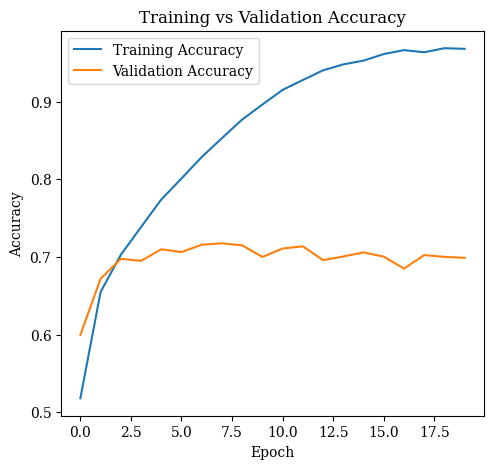

In [ ]:
#Accuracy Plots

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
#save_plot("plot3_accuracy")
plt.show()

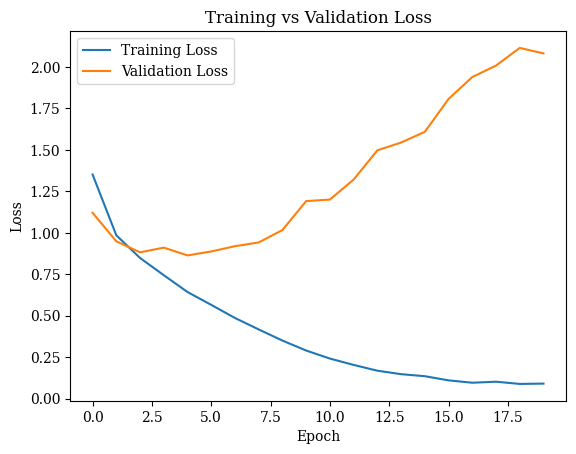

In [ ]:
#Loss plots


plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
#save_plot("plot4_loss")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7242 - loss: 0.8905

Test Accuracy : 0.7242000102996826
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Accuracy : 0.7242
Precision : 0.7270026512639404
Recall : 0.7242
F1 Score : 0.7228627548182888

Classification Report

              precision    recall  f1-score   support

    airplane       0.70      0.82      0.76      1000
  automobile       0.87      0.82      0.85      1000
        bird       0.61      0.62      0.61      1000
         cat       0.57      0.54      0.56      1000
        deer       0.70      0.63      0.66      1000
         dog       0.67      0.61      0.64      1000
        frog       0.72      0.86      0.78      1000
       horse       0.74      0.77      0.76      1000
        ship       0.89      0.72      0.80      1000
       truck       0.78      0.85      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot5_confusion_matrix.eps


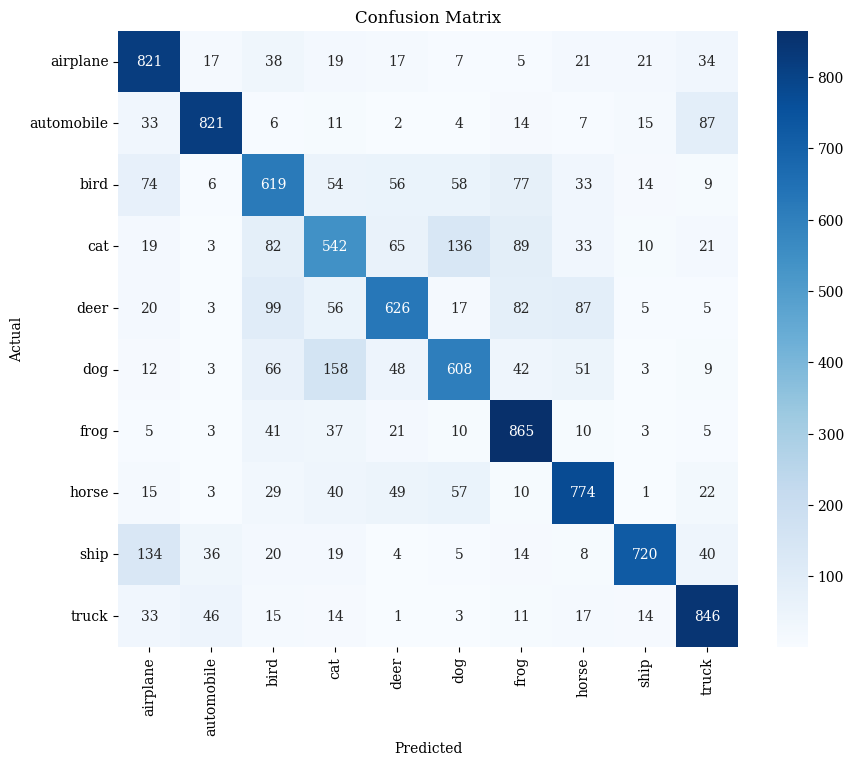

In [ ]:
#Model Evaluation


loss, accuracy = model.evaluate(x_test,y_test_cat)

print("\nTest Accuracy :",accuracy)

pred_prob = model.predict(x_test)

y_pred = np.argmax(pred_prob,axis=1)
y_true = y_test.flatten()



acc = accuracy_score(y_true,y_pred)
print("\nAccuracy :",acc)



precision = precision_score(y_true,y_pred,average='weighted')
print("Precision :",precision)

recall = recall_score(y_true,y_pred,average='weighted')
print("Recall :",recall)

f1 = f1_score(y_true,y_pred,average='weighted')
print("F1 Score :",f1)



print("\nClassification Report\n")
print(classification_report(y_true,y_pred,target_names=class_names))

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
save_plot("plot5_confusion_matrix")
plt.show()

In [ ]:
y_pred_prob = cnn_model.predict(
    x_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = y_test.flatten()

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
True labels shape: (10000,)
Predicted labels shape: (10000,)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy  : 0.6988
Precision : 0.7002
Recall    : 0.6988
F1-score  : 0.6984


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    airplane       0.75      0.74      0.74      1000
  automobile       0.80      0.85      0.82      1000
        bird       0.59      0.62      0.61      1000
         cat       0.50      0.48      0.49      1000
        deer       0.68      0.59      0.63      1000
         dog       0.58      0.61      0.59      1000
        frog       0.69      0.80      0.74      1000
       horse       0.77      0.73      0.75      1000
        ship       0.84      0.80      0.82      1000
       truck       0.80      0.77      0.79      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot6_feature_maps_conv_layer_1.eps


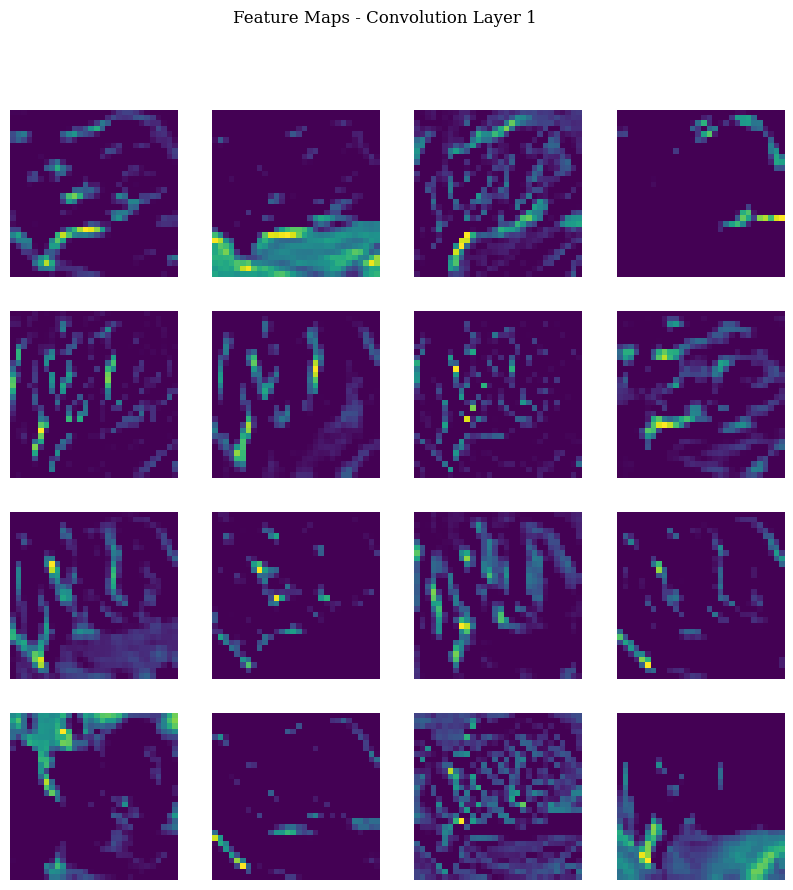

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot6_feature_maps_conv_layer_2.eps


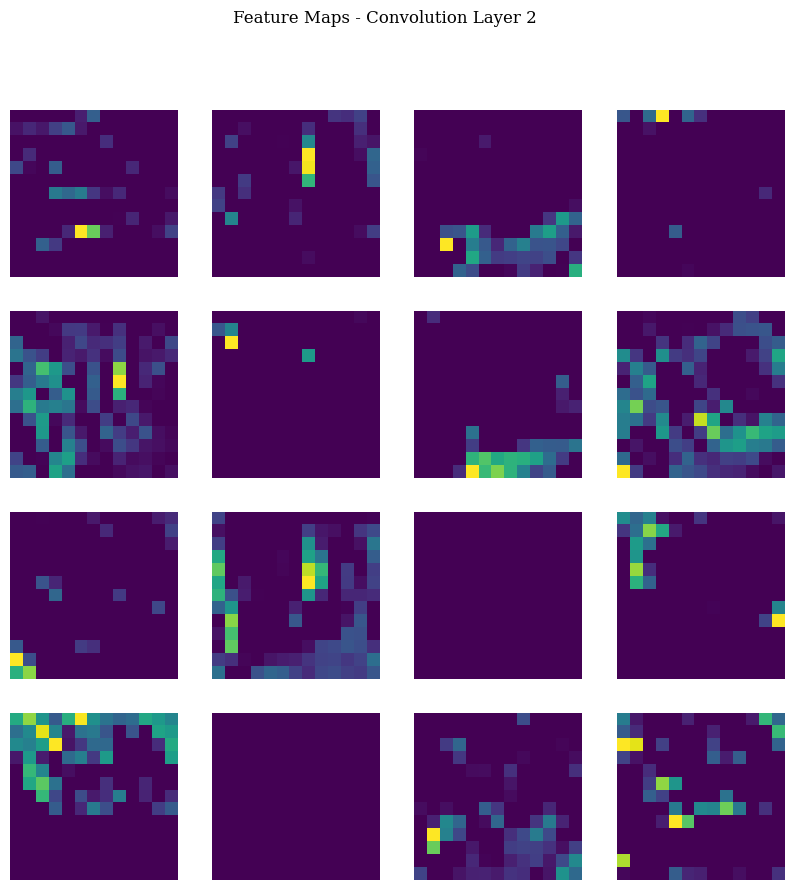

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot6_feature_maps_conv_layer_3.eps


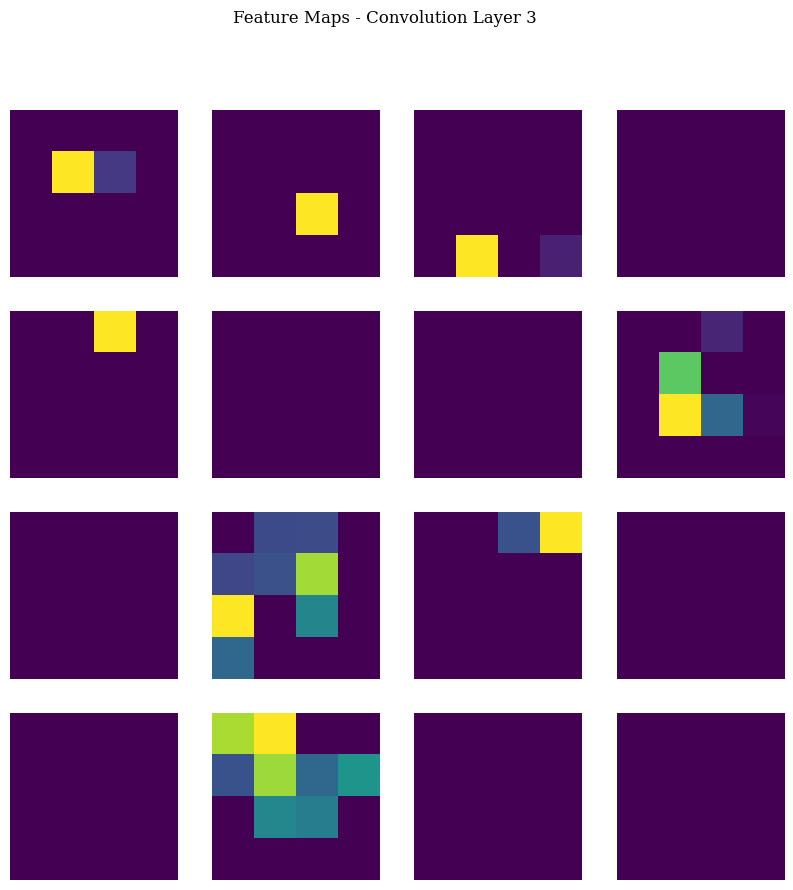

In [ ]:
import tensorflow as tf

#Feature Map

layer_outputs = [layer.output for layer in model.layers
                 if isinstance(layer, tf.keras.layers.Conv2D)]

activation_model = tf.keras.models.Model(
    inputs=model.layers[0].input, # Use the input of the first layer
    outputs=layer_outputs
)

sample = np.expand_dims(x_test[0],axis=0)

feature_maps = activation_model.predict(sample)

for layer_num, fmap in enumerate(feature_maps):

    plt.figure(figsize=(10,10))

    n_features = min(16, fmap.shape[-1])

    for i in range(n_features):

        plt.subplot(4,4,i+1)
        plt.imshow(fmap[0,:,:,i], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f"Feature Maps - Convolution Layer {layer_num+1}")
    save_plot(f"plot6_feature_maps_conv_layer_{layer_num+1}")
    plt.show()